In [72]:
import sympy
from sympy import Expr, Add, Symbol, simplify, expand, symbols, init_printing, I, pi
from sympy.physics.secondquant import B, Bd, Creator, Annihilator, Commutator

from typing import Callable, Tuple
init_printing()

def filter_terms(expr:Expr, func:Callable[[Expr], bool]):
    expanded_expr = expand(expr)

    if isinstance(expanded_expr, Add):
        terms = expanded_expr.args
    else:
        terms = [expanded_expr]
    
    output_terms = []

    for term in terms:
        if func(term):
            output_terms.append(term)
    
    return Add(*output_terms)

def boson_normal_order(expr, ops:Tuple[Creator, Annihilator]):
    """
    Enforces [a, a_dag] = 1 commutation relation & moves creation operators to the front of each term.
    """
    
    commutator = (ops[1]*ops[0], ops[0]*ops[1] + 1)
    curr_expr = expand(expr)
    while True:
        next_expr = expand(curr_expr.subs(*commutator))
        if next_expr == curr_expr:
            break
        curr_expr = next_expr
    
    return curr_expr

def remove_diagonal_terms(expr, ops:Tuple[Creator, Annihilator]):
    """
    Removes all terms that dont conserve n = ad*a (aka any terms that have a different # of creation & annihilation operators
    """
    def _filter(term:Expr):
        powers = term.as_powers_dict()
        return powers.get(ops[0], 0) == powers.get(ops[1], 0)
    
    return filter_terms(expr, _filter)

def get_eigenvalue_from_ladder_ops(expr, n:Symbol, ops:Tuple[Creator, Annihilator]):
    """
    Gets the eigenvalue of an expression by replacing all ad*a with n and removing any terms that dont conserve n
    """
    return expr.subs({ops[1]*ops[0]: n}).simplify()

In [73]:
a = B(0)
ad = Bd(0)
ladder_ops = (ad, a)

expr = (ad + a)**4
result = boson_normal_order(expr, ladder_ops)

display(expr)
display(result)
remove_diagonal_terms(result, ladder_ops)

x = Commutator(ad*a, a)
boson_normal_order(simplify(x), ladder_ops)

Hamiltonian for Anharmonic Duffing Oscillator

$H_D = \hbar(\omega_q a^\dag a + \frac{\alpha}{2}a^\dag a^\dag a a)$

In [74]:
from sympy import Rational, Pow, Eq, sqrt, solve, powdenest, factorial
from sympy.physics.quantum.constants import hbar

EC, EJ, omega_q0, omega_q = symbols(r'E_C, E_J, \omega_{q0}, \omega_q', positive=True)
alpha = symbols(r'\alpha', real=True)

phi = Pow(2*EC/EJ, Rational(1,4)) * (ad + a)
n = I*Pow(EJ/(32*EC), Rational(1,4)) * (ad - a)

omega_q0_subs = (EJ, solve(Eq(omega_q0, sqrt(8*EJ*EC) / hbar), EJ)[0])

# Add E0 to cancel out ground state energy
E0 = (EJ - hbar*omega_q0/2) + (EC/4)
cos_phi = 1 - Rational(1,2)*phi**2 + Rational(1,factorial(4))*phi**4
H = 4*EC*n**2 - EJ*cos_phi + E0
H = H.subs([omega_q0_subs]).simplify()
H = boson_normal_order(H, ladder_ops)
display(H)
H_diag = remove_diagonal_terms(H, ladder_ops)
display(H_diag)

omega_q_subs = (omega_q0, solve(Eq(hbar*omega_q, hbar*omega_q0-EC), omega_q0)[0])
alpha_subs = (EC, solve(Eq(alpha, -EC / hbar), EC)[0])
H_diag = H_diag.subs([omega_q_subs, alpha_subs]).simplify().expand()
display(H_diag)

In [75]:
# Find error bound from phi^6 term
H_error = -EJ*Rational(1,factorial(6))*phi**6
H_error = boson_normal_order(H_error, ladder_ops)
H_error = remove_diagonal_terms(H_error, ladder_ops)
display(H_error.simplify())
H_error = H_error.subs([omega_q0_subs, alpha_subs]).simplify()
display(H_error)
print(H_error)

-hbar*\alpha**2*(3 + 18*CreateBoson(0)*AnnihilateBoson(0) + 18*CreateBoson(0)**2*AnnihilateBoson(0)**2 + 4*CreateBoson(0)**3*AnnihilateBoson(0)**3)/(18*\omega_{q0})


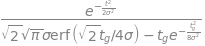

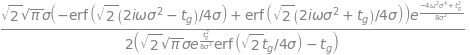

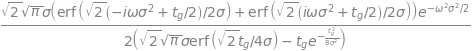

In [76]:
from sympy import Heaviside

a = symbols('a', positive=True)
sigma, tg = symbols('sigma t_g', positive=True)
t, omega = symbols('t omega', real=True)

B = sympy.exp(-(tg**2) / (8*sigma**2))
gaussian = (sympy.exp(-t**2 / (2*sigma**2))) / (sqrt(2*pi)*sigma*sympy.erf(tg / (sqrt(8)*sigma)) - tg*B)
display(gaussian)
fourier = sympy.fourier_transform((Heaviside(t+tg/2) - Heaviside(t-tg/2)) * gaussian, t, omega/(2*pi))

c1 = 1 / (sqrt(2*pi)*sigma*sympy.erf(tg / (sqrt(8)*sigma)) - tg*B)
z = (tg/2 + I*sigma**2*omega) / (sqrt(2)*sigma)
fourier2 = c1 * sqrt(2*pi)*sigma * sympy.exp(-(sigma*omega)**2 / 2) * (sympy.erf(z) + sympy.erf(sympy.conjugate(z)))/2

display(fourier)
display(fourier2)

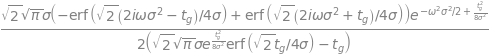

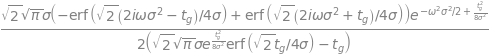

In [77]:
display(simplify(fourier))
display(simplify(fourier2))
display(simplify(fourier - fourier2))

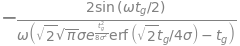

In [ ]:

window_fourier = sympy.fourier_transform((Heaviside(t+tg/2) - Heaviside(t-tg/2)), t, omega/(2*pi))
display(simplify(window_fourier))